In [ ]:
import torch
import matplotlib.pyplot as plt
from pancast10 import Core2MapModel, IterableShardDataset, BATCH_SIZE, LEAD_TIME

In [47]:
# === Load the checkpoint ===
checkpoint_path = "/home/users/mendrika/pancast-self/9bmd4qbe/checkpoints/best-core2map.ckpt"
model = Core2MapModel.load_from_checkpoint(checkpoint_path)

model.eval()
model.freeze() 

In [48]:
# === Load one test sample ===
shard_path = "/work/scratch-nopw2/mrakotomanga/eps/pancast-shard-processed/t1/test_512/t1-shard-test-006_proc.pt"
shard = torch.load(shard_path, map_location="cpu")

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [50]:
idx = 100

# Pick one sample
x = shard["inputs"][idx].unsqueeze(0).float()     # (1, 140, 9)
y = shard["targets"][idx].unsqueeze(0).float()    # (1, 512, 512)

# Move to device
x = x.cuda()  # or .to(device)

# === Inference ===
with torch.no_grad():
    pred = torch.sigmoid(model(x))  # shape: (1, 1, 512, 512)

# Optional: remove channel dimension
pred = pred.squeeze(0).squeeze(0)   # (512, 512)

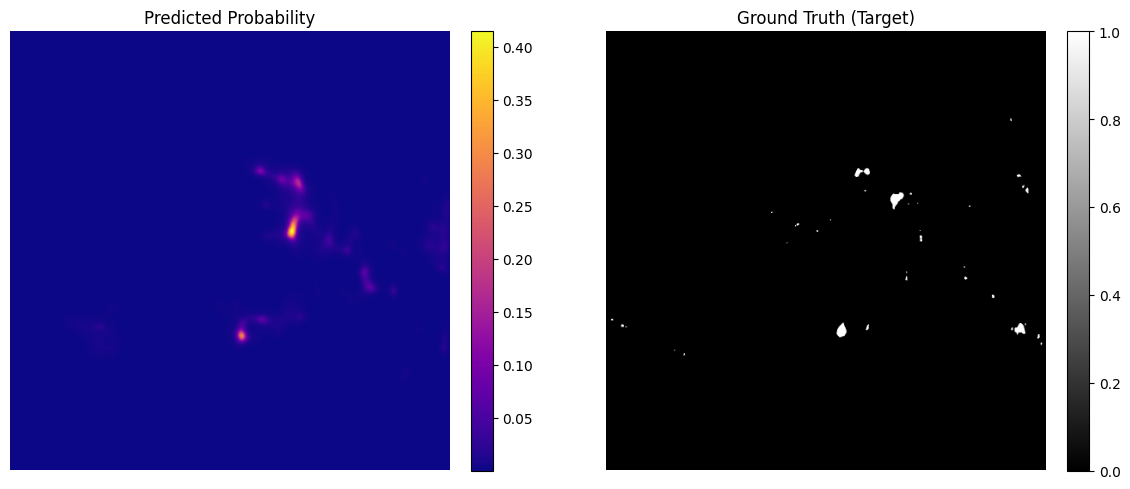

In [51]:
# Move to CPU and convert to numpy
pred_np = pred.detach().cpu().squeeze().numpy()
y_np    = y.detach().cpu().squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot predicted probability
im0 = axes[0].imshow(pred_np, cmap="plasma")
axes[0].set_title("Predicted Probability")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Plot ground truth
im1 = axes[1].imshow(y_np, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Ground Truth (Target)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# Compute FSS

In [52]:
import numpy as np
from scipy.ndimage import uniform_filter

def compute_fss(pred_np, y_np, threshold=0.2, window=9):
    # Binarise
    pred_bin = (pred_np >= threshold).astype(np.float32)
    y_bin = (y_np >= threshold).astype(np.float32)

    # Smooth using uniform filter
    kernel_size = window
    pred_smooth = uniform_filter(pred_bin, size=kernel_size, mode="constant")
    y_smooth = uniform_filter(y_bin, size=kernel_size, mode="constant")

    # Compute FSS
    mse_f = np.mean((pred_smooth - y_smooth) ** 2)
    mse_ref = np.mean(pred_smooth ** 2 + y_smooth ** 2)

    fss = 1.0 - (mse_f / (mse_ref + 1e-8))  # avoid division by zero

    return fss

# Example usage
fss_score = compute_fss(pred_np, y_np, threshold=0.1, window=9)
fss_score

np.float32(0.13396525)

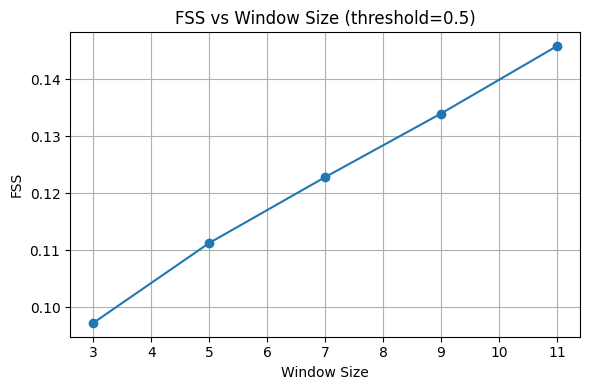

In [53]:
def compute_fss(pred_np, y_np, threshold=0.5, window=9):
    pred_bin = (pred_np >= threshold).astype(np.float32)
    y_bin = (y_np >= threshold).astype(np.float32)

    pred_smooth = uniform_filter(pred_bin, size=window, mode="constant")
    y_smooth = uniform_filter(y_bin, size=window, mode="constant")

    mse_f = np.mean((pred_smooth - y_smooth) ** 2)
    mse_ref = np.mean(pred_smooth ** 2 + y_smooth ** 2)

    fss = 1.0 - (mse_f / (mse_ref + 1e-8))  # small epsilon to prevent division by 0
    return fss

# Varying window sizes
window_sizes = [3, 5, 7, 9, 11]
fss_scores = [compute_fss(pred_np, y_np, threshold=0.1, window=w) for w in window_sizes]

# Plot FSS vs window size
plt.figure(figsize=(6, 4))
plt.plot(window_sizes, fss_scores, marker='o')
plt.title("FSS vs Window Size (threshold=0.5)")
plt.xlabel("Window Size")
plt.ylabel("FSS")
plt.grid(True)
plt.tight_layout()
plt.show()
